# GWT Reference-System Recovery

This notebook implements the two-stage reference-system diagnostic for the current validated joint GWT baseline.

- **Stage 1**: post-hoc free-`C` recovery curves for Human and ELIZA under the anchored baseline posterior.
- **Stage 2**: optional one-anchor-at-a-time refits under the same shared-`a`, shared-`kappa`, no-`b_e` baseline structure.

The post-hoc curve is intentionally favorable to the anchored model because the lower-layer parameters were learned with Human and ELIZA fixed. Failure there is therefore especially concerning; success is reassuring but not the final word.

In [1]:
import os, sys, warnings
from pathlib import Path

os.environ["PYTENSOR_FLAGS"] = f"compiledir=/tmp/pytensor_cache_nb15_{os.getpid()}"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplcache")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/.cache")
warnings.filterwarnings("ignore", message="Loop fusion failed")

repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.chdir(repo_root)

from gwt_reference_recovery_analysis import (
    DEFAULT_SMOKE_FIT_OVERRIDES,
    build_interpretation_note,
    extract_free_c_draws,
    format_refit_delta_table,
    format_system_summary_table,
    plot_recovery_curve,
    plot_recovery_overlay,
    prepare_anchored_baseline,
    run_one_anchor_refits,
    run_posthoc_reference_recovery,
    save_recovery_figures,
    summarise_recovery_curve,
)


## Run Configuration

Use `ANCHORED_IDATA_PATH` to load a previously saved anchored baseline if you already have one. Leave it as `None` to fit from scratch.

The refits default to smoke settings. Flip `RUN_FULL_REFITS` to `True` only when you want the real one-anchor runs.

In [2]:
ANCHORED_IDATA_PATH = None
ANCHORED_FIT_OVERRIDES = None

RUN_SMOKE_REFITS = True
RUN_FULL_REFITS = False

if RUN_SMOKE_REFITS and RUN_FULL_REFITS:
    raise ValueError("Choose either smoke refits or full refits, not both")

if RUN_FULL_REFITS:
    REFIT_FIT_OVERRIDES = None
elif RUN_SMOKE_REFITS:
    REFIT_FIT_OVERRIDES = dict(DEFAULT_SMOKE_FIT_OVERRIDES)
else:
    REFIT_FIT_OVERRIDES = None

SAVE_DIR = Path("report_figures")
SAVE_DIR.mkdir(exist_ok=True)


## Anchored Baseline Context

This prepares the current source-of-truth baseline: shared tree parameters, shared observation layer, no expert shifts, no hierarchical cutpoints, Human fixed at `0.999`, ELIZA fixed at `0.001`.

In [3]:
baseline = prepare_anchored_baseline(
    idata_path=ANCHORED_IDATA_PATH,
    fit_overrides=ANCHORED_FIT_OVERRIDES,
    verbose=True,
)

print(format_system_summary_table(baseline["c_summary"], baseline["system_configs"]))
print("\nDiagnostics:")
print(baseline["diagnostics"])


Fitting anchored GWT baseline...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somato

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 918 seconds.


anchored baseline elapsed_s=16719.9
System                         median         94% interval   status
----------------------------------------------------------------------
Human                           0.999 [0.999, 0.999]     free
Chicken                         0.249 [0.017, 0.655]     free
LLMs                            0.081 [0.004, 0.361]     free
ELIZA                           0.001 [0.001, 0.001]     free

Diagnostics:
{'divergences': 0, 'max_rhat': 1.0, 'min_ess': 6220.0}


## Stage 1: Post-Hoc Free-`C` Recovery Curves

For each reference system, compute

$$p(c \mid y_{\rm sys}, \text{anchored posterior}) \propto p(c) \, \mathbb{E}_{\theta \sim p(\theta \mid y_{\rm all}, \text{anchors})}[p(y_{\rm sys} \mid c, \theta)]$$

using the tree-implied indicator probabilities `..._p`, not the leaf-updated `..._pz1`.

Human post-hoc free-C recovery
  likelihood-only: median=0.880  [0.418, 0.994]  mode=0.999
  Beta(1, 5) posterior: median=0.343  [0.025, 0.736]  mode=0.335  P(C > 0.95)=0.000
  anchor=0.999
ELIZA post-hoc free-C recovery
  likelihood-only: median=0.126  [0.004, 0.592]  mode=0.001
  Beta(1, 5) posterior: median=0.069  [0.002, 0.321]  mode=0.001  P(C < 0.05)=0.388
  anchor=0.001


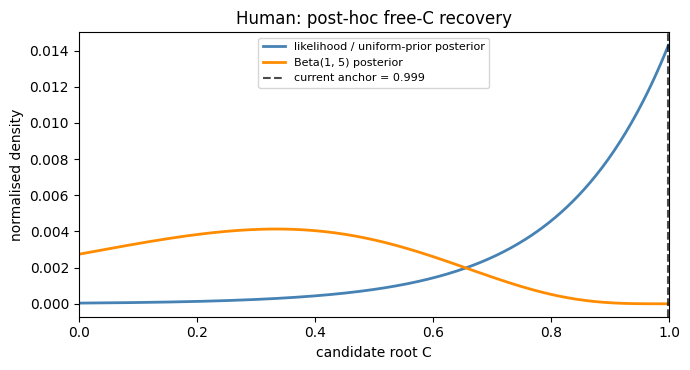

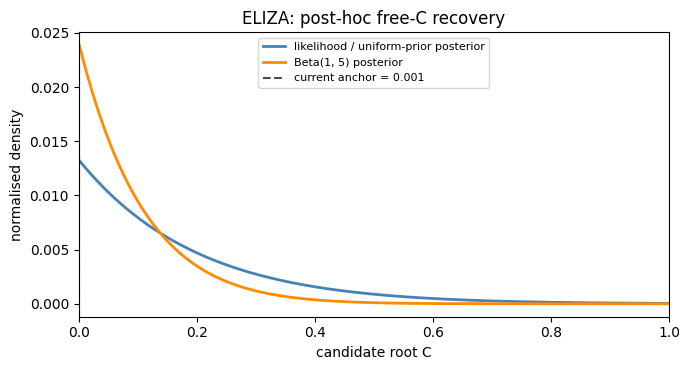

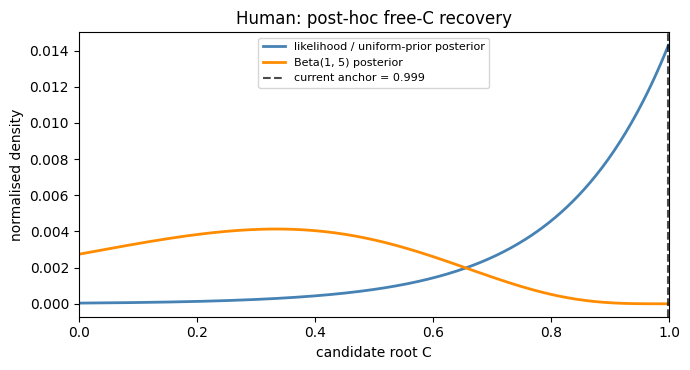

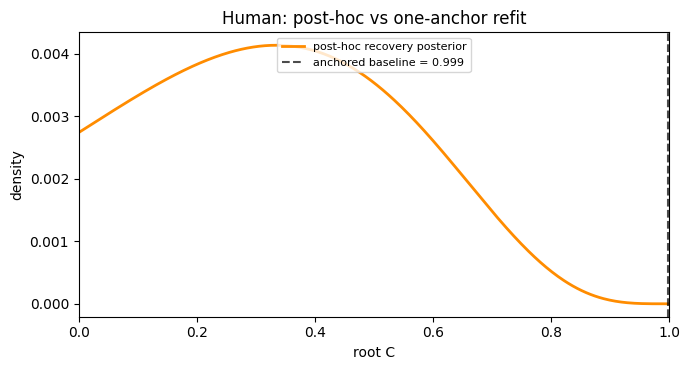

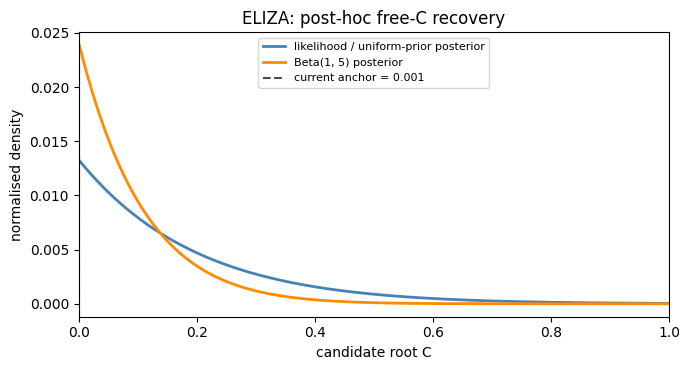

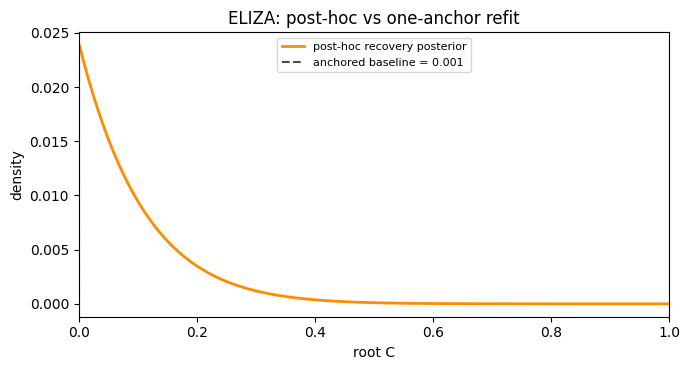

In [4]:
curves = {}
for system_name in ("Human", "ELIZA"):
    curves[system_name] = run_posthoc_reference_recovery(
        baseline["idata"],
        baseline["builder"],
        baseline["processor"],
        baseline["stance_data"],
        system_name,
    )
    print(summarise_recovery_curve(curves[system_name]))
    plot_recovery_curve(curves[system_name])

save_recovery_figures(curves, refit_results=None, save_dir=SAVE_DIR)


## Stage 2: Optional One-Anchor Refits

These refits keep the validated baseline structure fixed and only free one reference at a time:

- Human free, ELIZA fixed
- ELIZA free, Human fixed

By default this cell runs the smoke settings only.

In [ ]:
refit_results = {}
if REFIT_FIT_OVERRIDES is not None or RUN_FULL_REFITS:
    refit_results = run_one_anchor_refits(
        stance_data=baseline["stance_data"],
        fit_overrides=REFIT_FIT_OVERRIDES,
        include_anchored=False,
        verbose=True,
    )
    for label, result in refit_results.items():
        print(f"\n=== {label} ===")
        print(
            format_system_summary_table(result["c_summary"], result["system_configs"])
        )
        print("Diagnostics:", result["diagnostics"])
        print(format_refit_delta_table(baseline["c_summary"], result["c_summary"]))
else:
    print(
        "Refits skipped; set RUN_SMOKE_REFITS or RUN_FULL_REFITS to True to enable them."
    )


Fitting systems=[('Human', None), ('Chicken', None), ('2024 Leading Chat LLMs', None), ('ELIZA', 0.001)]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [human__global_workspace_theory_C, chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatot

Output()

Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1228 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fitting systems=[('Human', 0.999), ('Chicken', None), ('2024 Leading Chat LLMs', None), ('ELIZA', None)]


Initializing NUTS using jitter+adapt_diag...


KeyboardInterrupt: 

In [7]:
if refit_results:
    save_recovery_figures(curves, refit_results=refit_results, save_dir=SAVE_DIR)
    for system_name, label in (("Human", "human_free"), ("ELIZA", "eliza_free")):
        draws = extract_free_c_draws(
            refit_results[label]["idata"],
            refit_results[label]["builder"],
            system_name,
        )
        plot_recovery_overlay(curves[system_name], refit_draws=draws)


## Interpretation Note

This prints a short notebook-ready interpretation block answering the four main questions for the iteration.

In [8]:
print(
    build_interpretation_note(
        curves,
        refit_results=refit_results,
        baseline_summary=baseline["c_summary"],
    )
)


Stage 1 is a favorable-but-not-final check: theta was learned under fixed Human / ELIZA anchors, so failure here would be especially concerning, while success is only reassuring rather than decisive.
Human post-hoc: median 0.343 [0.025, 0.736], P(C > 0.95) = 0.000.
ELIZA post-hoc: median 0.069 [0.002, 0.321], P(C < 0.05) = 0.388.
Human and ELIZA remain single-expert cells in the current GWT data, so weak recovery is a substantive result to report plainly rather than an automatic implementation failure.
